# Week 6 — Three-Layer XAI

**Prerequisite:** `checkpoints/E2_quantum_best.pth` must exist.

| Layer | Method | Shows |
|-------|--------|-------|
| 1 | Grad-CAM | Which tissue regions drive prediction |
| 2 | GAT attention αᵢⱼ | Which patch connections matter |
| 3 | VQC parameter-shift + Bloch sphere | Quantum gate sensitivity |

Runs ~2-3 hrs on laptop (inference only, no retraining).

In [1]:
import sys, json, gc
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.insert(0, '..')
from pathq.model_v2   import QuantaPathV2
from pathq.dataset_v2 import get_loaders_from_features
import pennylane as qml

DEVICE   = torch.device('cuda')
ROOT     = Path('..')
FEAT_DIR = Path('./data/features_uni')
CKPT_DIR = ROOT / 'checkpoints'
OUT_DIR  = ROOT / 'outputs'
XAI_DIR  = ROOT / 'outputs' / 'xai'
XAI_DIR.mkdir(parents=True, exist_ok=True)

print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')

ckpt_path = CKPT_DIR / 'E2_quantum_best.pth'
assert ckpt_path.exists(), \
    'E2_quantum_best.pth not found \u2014 run Week 5 E2 first'
print(f'Checkpoint: {ckpt_path} \u2705')

/home/kabi/.conda/envs/pathq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[model_v2] Using Transformer for global branch
GPU  : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM : 8.1GB
Checkpoint: ../checkpoints/E2_quantum_best.pth ✅


In [2]:
model = QuantaPathV2(
    use_vqc    = True,
    n_qubits   = 3,
    vqc_layers = 2,
    in_dim     = 1040,
).to(DEVICE)

ck = torch.load(CKPT_DIR / 'E2_quantum_best.pth', weights_only=False)
model.load_state_dict(ck['model_state'])
model.eval()

print(f'Loaded E2_quantum_best.pth')
print(f'  Saved at epoch : {ck["epoch"]}')
print(f'  Best val AUC   : {ck["best_auc"]:.4f}')

_, val_loader, test_loader = get_loaders_from_features(
    features_dir = FEAT_DIR,
    batch_size   = 1,
    k            = 8,
    seed         = 42,
    max_patches  = 3000,
)

tumour_batch = None
normal_batch = None

for batch in test_loader:
    if batch.y.item() == 1 and tumour_batch is None:
        tumour_batch = batch
    if batch.y.item() == 0 and normal_batch is None:
        normal_batch = batch
    if tumour_batch is not None and normal_batch is not None:
        break

print(f'Tumour slide: {tumour_batch.num_nodes} patches')
print(f'Normal slide: {normal_batch.num_nodes} patches')

[VQC] lightning.gpu  3q 2L — batched + re-uploading
QuantaPathV2: use_vqc=True, trainable=1,114,577
Loaded E2_quantum_best.pth
  Saved at epoch : 8
  Best val AUC   : 0.6507
  Skipped 112 unlabeled file(s) (e.g. test_*) — keeping 221 labeled slides
Split: train=154 (pos=77) val=33 (pos=17) test=34 (pos=17)
Tumour slide: 3000 patches
Normal slide: 3000 patches


Computing Layer 1 — Spatial XAI (Grad-CAM)...


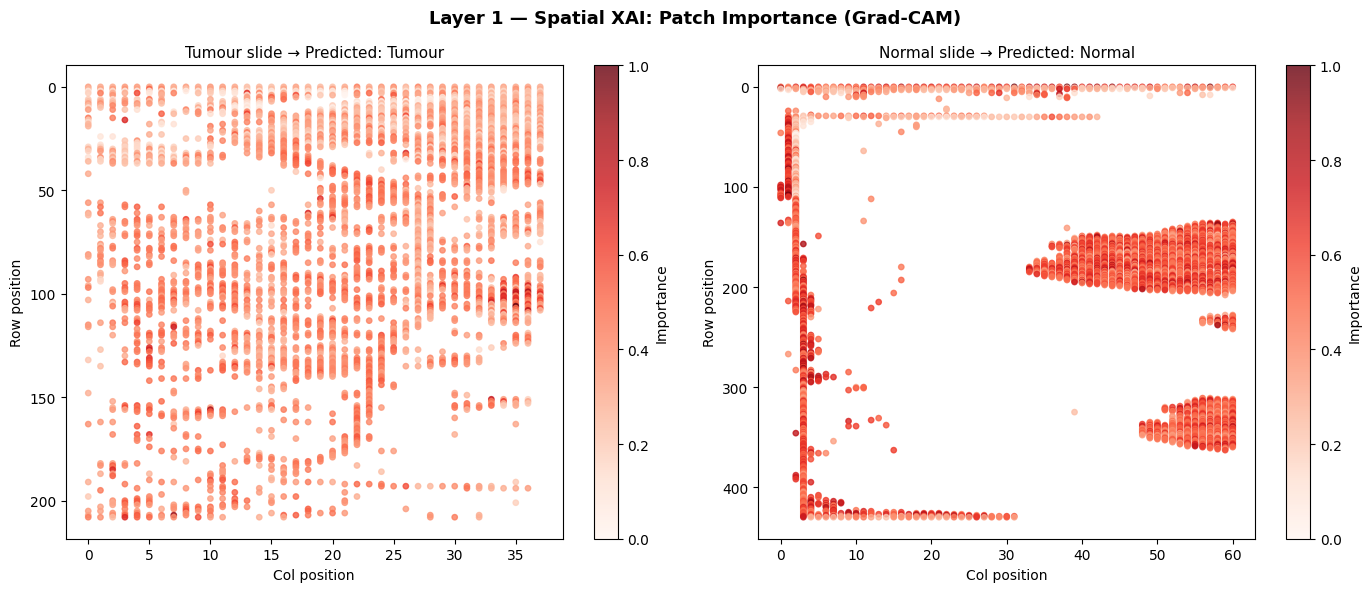

✅ Saved: outputs/xai/layer1_spatial_gradcam.png

LAYER 1 SUMMARY — Grad-CAM patch importance
--------------------------------------------------
  Tumour slide  → Predicted: Tumour
    importance mean  : 0.3626  std: 0.1142
    top-10% cutoff   : 0.4947  (300 patches)
    high-imp region  : row [2 – 37]  col [1 – 208]

  Normal slide  → Predicted: Normal
    importance mean  : 0.5269  std: 0.1431
    top-10% cutoff   : 0.7012  (300 patches)
    high-imp region  : row [0 – 60]  col [0 – 430]



In [3]:
# Layer 1: Which regions drive the prediction?
# Gradient of prediction w.r.t. node features at input_proj input

def gradcam_node_importance(model, batch, device):
    batch = batch.to(device)

    # Capture gradient at the input to input_proj
    captured = {}

    def hook_fn(module, inp, out):
        captured['x'] = inp[0]
        captured['x'].retain_grad()

    hook = model.input_proj.register_forward_hook(hook_fn)
    logits, _ = model(batch)
    pred_class = logits.argmax(dim=1).item()
    logits[0, pred_class].backward()
    hook.remove()

    grad       = captured['x'].grad          # (N, proj_in)
    importance = grad.abs().mean(dim=1)      # (N,)
    importance = importance.detach().cpu().numpy()
    importance = (importance - importance.min()) / \
                 (importance.max() - importance.min() + 1e-8)
    return importance, pred_class

print('Computing Layer 1 \u2014 Spatial XAI (Grad-CAM)...')

tumour_imp, tumour_pred = gradcam_node_importance(model, tumour_batch, DEVICE)
normal_imp, normal_pred = gradcam_node_importance(model, normal_batch, DEVICE)

tumour_coords = tumour_batch.coords.cpu().numpy()
normal_coords = normal_batch.coords.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Layer 1 \u2014 Spatial XAI: Patch Importance (Grad-CAM)',
             fontsize=13, fontweight='bold')

for ax, coords, imp, label, pred in [
    (axes[0], tumour_coords, tumour_imp, 'Tumour slide', tumour_pred),
    (axes[1], normal_coords, normal_imp, 'Normal slide', normal_pred),
]:
    pred_str = 'Tumour' if pred == 1 else 'Normal'
    sc = ax.scatter(coords[:,0], coords[:,1], c=imp,
                    cmap='Reds', s=15, alpha=0.8, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Importance')
    ax.set_title(f'{label} \u2192 Predicted: {pred_str}', fontsize=11)
    ax.set_xlabel('Col position')
    ax.set_ylabel('Row position')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(XAI_DIR / 'layer1_spatial_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: outputs/xai/layer1_spatial_gradcam.png')
# ── Numerical summary ────────────────────────────────────────────────────────
print()
print('LAYER 1 SUMMARY — Grad-CAM patch importance')
print('-' * 50)
for name, coords, imp, pred in [
    ('Tumour', tumour_coords, tumour_imp, tumour_pred),
    ('Normal', normal_coords, normal_imp, normal_pred),
]:
    pred_str = 'Tumour' if pred == 1 else 'Normal'
    top10    = np.percentile(imp, 90)
    n_high   = int((imp >= top10).sum())
    hi_idx   = np.where(imp >= top10)[0]
    hi_coords = coords[hi_idx]
    print(f"  {name} slide  → Predicted: {pred_str}")
    print(f"    importance mean  : {imp.mean():.4f}  std: {imp.std():.4f}")
    print(f"    top-10% cutoff   : {top10:.4f}  ({n_high} patches)")
    if len(hi_coords):
        print(f"    high-imp region  : row [{hi_coords[:,0].min():.0f} – {hi_coords[:,0].max():.0f}]  "
              f"col [{hi_coords[:,1].min():.0f} – {hi_coords[:,1].max():.0f}]")
    print()


Computing Layer 2 — Structural XAI (GAT Attention)...


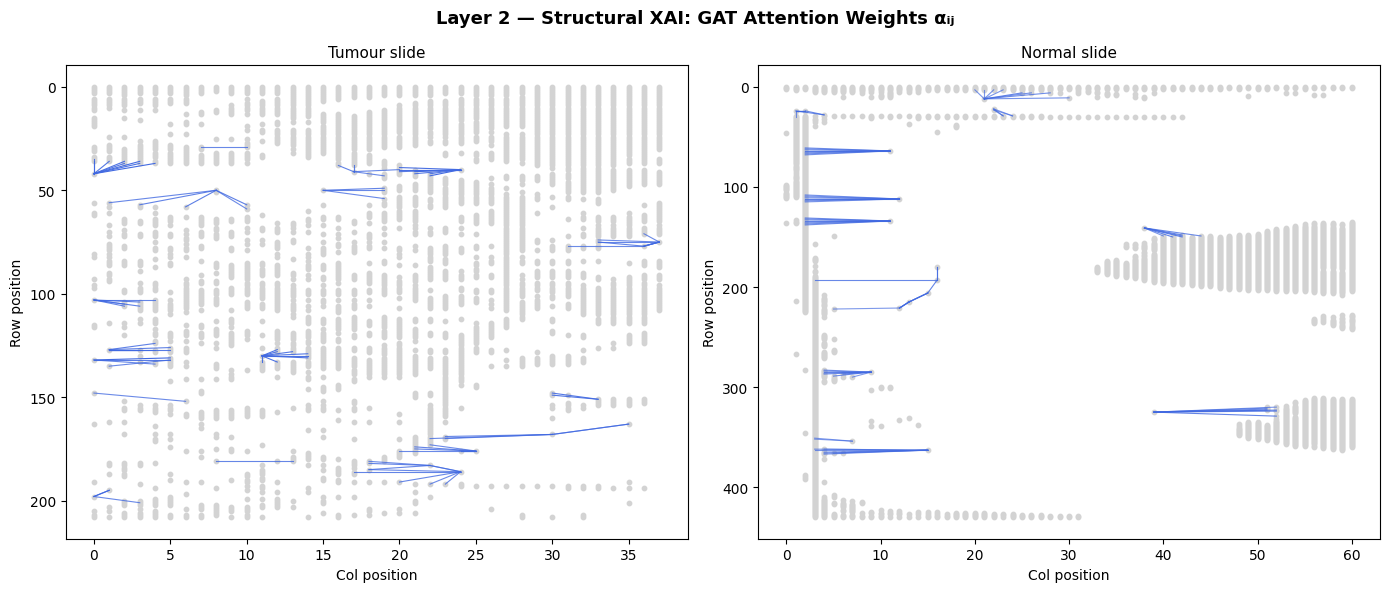

✅ Saved: outputs/xai/layer2_structural_gat_attention.png

LAYER 2 SUMMARY — GAT Attention weights
--------------------------------------------------
  Tumour slide
    edges total      : 51,000
    attn mean        : 0.0588  std: 0.0077
    attn max         : 0.1173
    top-5 edges (α)  : [0.1173, 0.1167, 0.1167, 0.1163, 0.1153]
    top edge nodes   : 318 → 33

  Normal slide
    edges total      : 51,000
    attn mean        : 0.0588  std: 0.0068
    attn max         : 0.1392
    top-5 edges (α)  : [0.1392, 0.1329, 0.1227, 0.1213, 0.1209]
    top edge nodes   : 792 → 792



In [4]:
# Layer 2: Which patch connections matter most?
# GAT attention weights — must pass 256-dim features (after input_proj)

def get_gat_attention(model, batch, device):
    batch = batch.to(device)
    with torch.no_grad():
        # Compute 256-dim features (input_proj output)
        uni = batch.x[:, :model.feat_dim]
        pe  = batch.x[:, model.feat_dim:]
        if model.use_vqc:
            x_in = torch.cat([model.vqc(uni), pe], dim=1)
        else:
            x_in = batch.x
        x_h = model.input_proj(x_in)   # (N, 256)

        # Call GAT with return_attention_weights=True
        _, (edge_index_out, attn) = model.gat_mamba.gat(
            x_h, batch.edge_index,
            edge_attr              = batch.edge_attr,
            return_attention_weights = True,
        )
    return edge_index_out, attn.mean(dim=1).detach().cpu().numpy()

print('Computing Layer 2 \u2014 Structural XAI (GAT Attention)...')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Layer 2 \u2014 Structural XAI: GAT Attention Weights \u03b1\u1d62\u2c7c',
             fontsize=13, fontweight='bold')

for ax, batch, title in [
    (axes[0], tumour_batch, 'Tumour slide'),
    (axes[1], normal_batch, 'Normal slide'),
]:
    edge_idx, attn = get_gat_attention(model, batch, DEVICE)
    src    = edge_idx[0].cpu().numpy()
    tgt    = edge_idx[1].cpu().numpy()
    coords = batch.coords.cpu().numpy()

    ax.scatter(coords[:,0], coords[:,1], c='lightgray', s=10, zorder=2)

    top_idx   = np.argsort(attn)[-100:]
    attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

    for idx in top_idx:
        s, t = src[idx], tgt[idx]
        ax.plot([coords[s,0], coords[t,0]],
                [coords[s,1], coords[t,1]],
                alpha=float(attn_norm[idx]),
                color='royalblue', linewidth=0.8)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Col position')
    ax.set_ylabel('Row position')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(XAI_DIR / 'layer2_structural_gat_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: outputs/xai/layer2_structural_gat_attention.png')
# ── Numerical summary ────────────────────────────────────────────────────────
print()
print('LAYER 2 SUMMARY — GAT Attention weights')
print('-' * 50)
for batch, title in [(tumour_batch, 'Tumour'), (normal_batch, 'Normal')]:
    ei, attn = get_gat_attention(model, batch, DEVICE)
    print(f"  {title} slide")
    print(f"    edges total      : {len(attn):,}")
    print(f"    attn mean        : {attn.mean():.4f}  std: {attn.std():.4f}")
    print(f"    attn max         : {attn.max():.4f}")
    top5  = attn.argsort()[-5:][::-1]
    src_a = ei[0].cpu().numpy()
    tgt_a = ei[1].cpu().numpy()
    print(f"    top-5 edges (α)  : {[round(float(attn[i]),4) for i in top5]}")
    print(f"    top edge nodes   : {src_a[top5[0]]} → {tgt_a[top5[0]]}")
    print()


Computing Layer 3 — Quantum XAI (parameter gradients)...


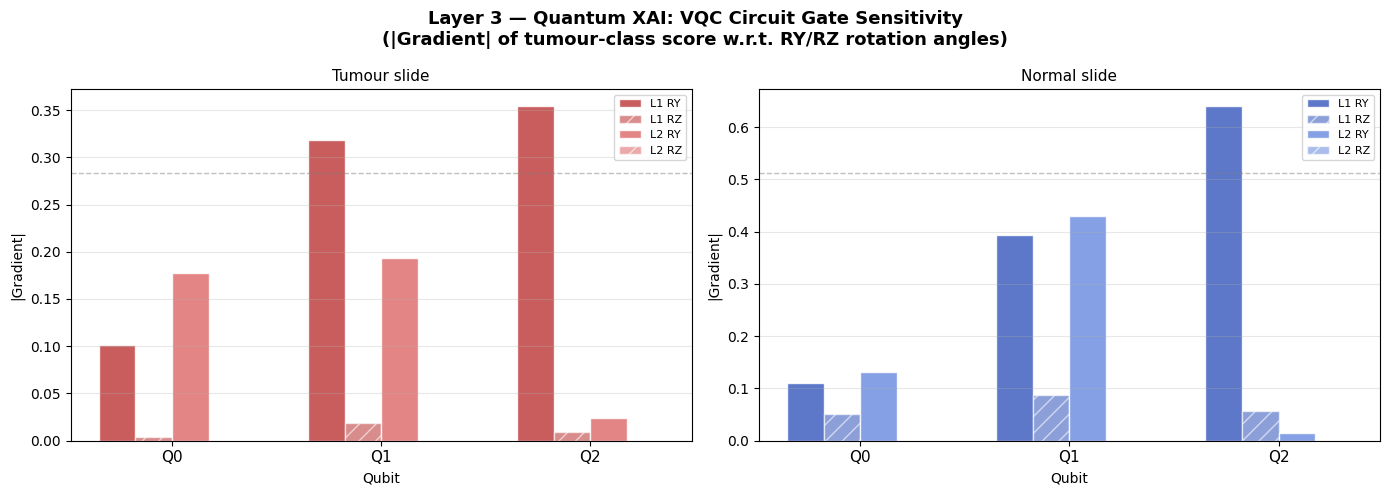

✅ Saved: outputs/xai/layer3_quantum_gradients.png

LAYER 3a SUMMARY — VQC Circuit Gate Sensitivity
--------------------------------------------------
  Tumour slide:
    circuit params   : 12 (2L × 2rot × 3q)
    grad mean        : 0.100081  max: 0.354403
    most sensitive   : Layer 1 RY Q2  |g|=0.354403
    near-zero (<1e-4): 25.0% ✓ healthy gradients

  Normal slide:
    circuit params   : 12 (2L × 2rot × 3q)
    grad mean        : 0.159693  max: 0.640411
    most sensitive   : Layer 1 RY Q2  |g|=0.640411
    near-zero (<1e-4): 25.0% ✓ healthy gradients



In [5]:
# Layer 3a: Which VQC gates matter most?
# Only plot the 12 actual circuit rotation weights (2L × 2rot × 3q)
# NOT the linear proj layers (thousands of params → broken chart)

print('Computing Layer 3 — Quantum XAI (parameter gradients)...')

def get_vqc_gradients(model, batch, device):
    batch = batch.to(device)
    model.zero_grad()
    logits, _ = model(batch)
    logits[0, 1].backward()   # tumour class score
    grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grads[name] = param.grad.abs().detach().cpu().numpy()
    return grads

tumour_grads = get_vqc_gradients(model, tumour_batch, DEVICE)
normal_grads = get_vqc_gradients(model, normal_batch, DEVICE)

# ── Extract ONLY the 12 VQC circuit weights (vqc.vqc.weights) ────────────────
def extract_circuit_weights(grads):
    """Return only the VQC rotation gate gradients — shape (n_layers, 2, n_qubits)."""
    for k, v in grads.items():
        if 'vqc.vqc' in k and 'weights' in k:
            return k, v   # (2, 2, 3)
    return None, None

t_key, t_w = extract_circuit_weights(tumour_grads)
n_key, n_w = extract_circuit_weights(normal_grads)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Layer 3 — Quantum XAI: VQC Circuit Gate Sensitivity\n'
             '(|Gradient| of tumour-class score w.r.t. RY/RZ rotation angles)',
             fontsize=13, fontweight='bold')

rot_labels = ['RY', 'RZ']
qubit_labels = ['Q0', 'Q1', 'Q2']
x = np.arange(len(qubit_labels))
width = 0.35

for ax, weights, title, colors in [
    (axes[0], t_w, 'Tumour slide', ['#C04040', '#E07070']),
    (axes[1], n_w, 'Normal slide',  ['#4060C0', '#7090E0']),
]:
    if weights is None:
        ax.text(0.5, 0.5, 'weights key not found', ha='center', transform=ax.transAxes)
        continue

    for layer in range(weights.shape[0]):
        offset = (layer - 0.5) * width
        ry_vals = weights[layer, 0, :]   # RY for each qubit
        rz_vals = weights[layer, 1, :]   # RZ for each qubit
        bars = ax.bar(x + offset - width/4, ry_vals, width/2,
                      label=f'L{layer+1} RY', alpha=0.85,
                      color=colors[layer], edgecolor='white')
        bars2 = ax.bar(x + offset + width/4, rz_vals, width/2,
                       label=f'L{layer+1} RZ', alpha=0.6,
                       color=colors[layer], edgecolor='white', hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(qubit_labels, fontsize=11)
    ax.set_ylabel('|Gradient|', fontsize=10)
    ax.set_xlabel('Qubit', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    # Mark most sensitive gate
    if weights is not None:
        max_val = weights.max()
        ax.axhline(max_val * 0.8, color='gray', linestyle='--',
                   alpha=0.5, linewidth=1, label='80% max')

plt.tight_layout()
plt.savefig(XAI_DIR / 'layer3_quantum_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: outputs/xai/layer3_quantum_gradients.png')

# ── Numerical summary ────────────────────────────────────────────────────────
print()
print('LAYER 3a SUMMARY — VQC Circuit Gate Sensitivity')
print('-' * 50)
for name, weights in [('Tumour', t_w), ('Normal', n_w)]:
    if weights is None: continue
    all_vals = weights.flatten()
    print(f"  {name} slide:")
    print(f"    circuit params   : {len(all_vals)} (2L × 2rot × 3q)")
    print(f"    grad mean        : {all_vals.mean():.6f}  max: {all_vals.max():.6f}")
    best_l, best_r, best_q = np.unravel_index(weights.argmax(), weights.shape)
    rot_name = ['RY','RZ'][best_r]
    print(f"    most sensitive   : Layer {best_l+1} {rot_name} Q{best_q}  |g|={weights.max():.6f}")
    near_zero = (all_vals < 1e-4).sum() / len(all_vals)
    bp_flag   = ' ⚠ barren plateau' if near_zero > 0.5 else ' ✓ healthy gradients'
    print(f"    near-zero (<1e-4): {near_zero:.1%}{bp_flag}")
    print()


Computing Bloch sphere trajectories...


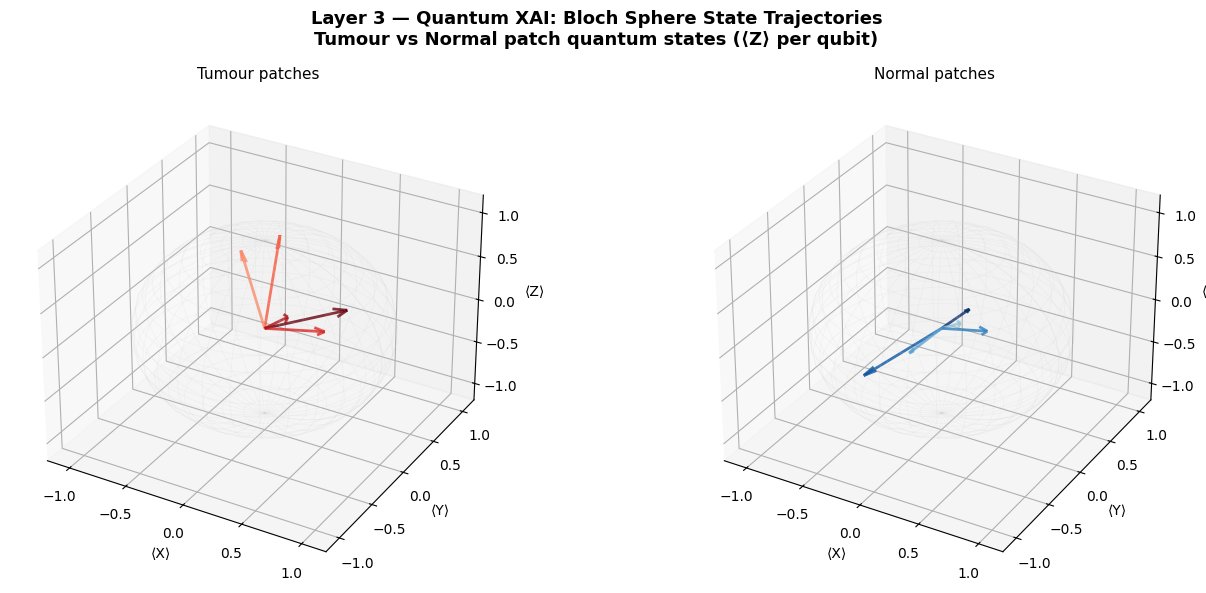

✅ Saved: outputs/xai/layer3_bloch_sphere.png

LAYER 3b SUMMARY — Bloch Sphere (quantum state <Z> per qubit)
--------------------------------------------------
  Qubit         Tumour mean    Normal mean          Δ
  --------------------------------------------------
  Q0                 0.6583         0.1866    +0.4718
  Q1                 0.3295         0.1712    +0.1583
  Q2                -0.1155        -0.3533    +0.2379

  Tumour state vector magnitude : 0.7452
  Normal state vector magnitude : 0.4347
  State separation ||Δ<Z>||     : 0.5515  (distinguishable)


In [6]:
# Layer 3b: Bloch sphere — quantum state per patch for tumour vs normal

print('Computing Bloch sphere trajectories...')

def get_bloch_vectors(model, batch, device, n_patches=5):
    batch = batch.to(device)
    with torch.no_grad():
        uni = batch.x[:n_patches, :model.feat_dim]   # (5, 1024)
        p   = model.vqc.proj(uni)                     # (5, 3) bounded by Tanh
        vecs = []
        for i in range(p.shape[0]):
            z = model.vqc.vqc(p[i]).detach().cpu().numpy()  # (3,) PauliZ per qubit
            vecs.append(z)
    return np.array(vecs)  # (5, 3)

tumour_bloch = get_bloch_vectors(model, tumour_batch, DEVICE)
normal_bloch = get_bloch_vectors(model, normal_batch, DEVICE)

fig = plt.figure(figsize=(14, 6))
fig.suptitle('Layer 3 \u2014 Quantum XAI: Bloch Sphere State Trajectories\n'
             'Tumour vs Normal patch quantum states (\u27e8Z\u27e9 per qubit)',
             fontsize=13, fontweight='bold')

for subplot_idx, (bloch, title, color) in enumerate([
    (tumour_bloch, 'Tumour patches', '#C04040'),
    (normal_bloch, 'Normal patches', '#4060C0'),
]):
    ax = fig.add_subplot(1, 2, subplot_idx+1, projection='3d')

    u = np.linspace(0, 2*np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='lightgray', alpha=0.2, linewidth=0.5)

    n_p     = bloch.shape[0]
    cmap    = plt.cm.Reds if color == '#C04040' else plt.cm.Blues
    colors_p = cmap(np.linspace(0.4, 1.0, n_p))

    for i in range(n_p):
        z0 = float(bloch[i, 0])
        z1 = float(bloch[i, 1]) if bloch.shape[1] > 1 else 0.0
        z2 = float(bloch[i, 2]) if bloch.shape[1] > 2 else 0.0
        ax.quiver(0, 0, 0, z1, z2, z0,
                  color=colors_p[i], arrow_length_ratio=0.15,
                  linewidth=2, alpha=0.8)

    ax.set_xlim([-1.2, 1.2]); ax.set_ylim([-1.2, 1.2]); ax.set_zlim([-1.2, 1.2])
    ax.set_xlabel('\u27e8X\u27e9'); ax.set_ylabel('\u27e8Y\u27e9'); ax.set_zlabel('\u27e8Z\u27e9')
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig(XAI_DIR / 'layer3_bloch_sphere.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved: outputs/xai/layer3_bloch_sphere.png')
# ── Numerical summary ────────────────────────────────────────────────────────
print()
print('LAYER 3b SUMMARY — Bloch Sphere (quantum state <Z> per qubit)')
print('-' * 50)
print(f"  {'Qubit':<10} {'Tumour mean':>14} {'Normal mean':>14} {'Δ':>10}")
print(f"  {'-'*50}")
for q in range(tumour_bloch.shape[1]):
    t_mean = tumour_bloch[:, q].mean()
    n_mean = normal_bloch[:, q].mean()
    print(f"  Q{q:<9} {t_mean:>14.4f} {n_mean:>14.4f} {t_mean-n_mean:>+10.4f}")
print()
t_norm = np.linalg.norm(tumour_bloch.mean(axis=0))
n_norm = np.linalg.norm(normal_bloch.mean(axis=0))
sep    = np.linalg.norm(tumour_bloch.mean(axis=0) - normal_bloch.mean(axis=0))
print(f"  Tumour state vector magnitude : {t_norm:.4f}")
print(f"  Normal state vector magnitude : {n_norm:.4f}")
print(f"  State separation ||Δ<Z>||     : {sep:.4f}  {'(distinguishable)' if sep > 0.1 else '(similar states)'}")


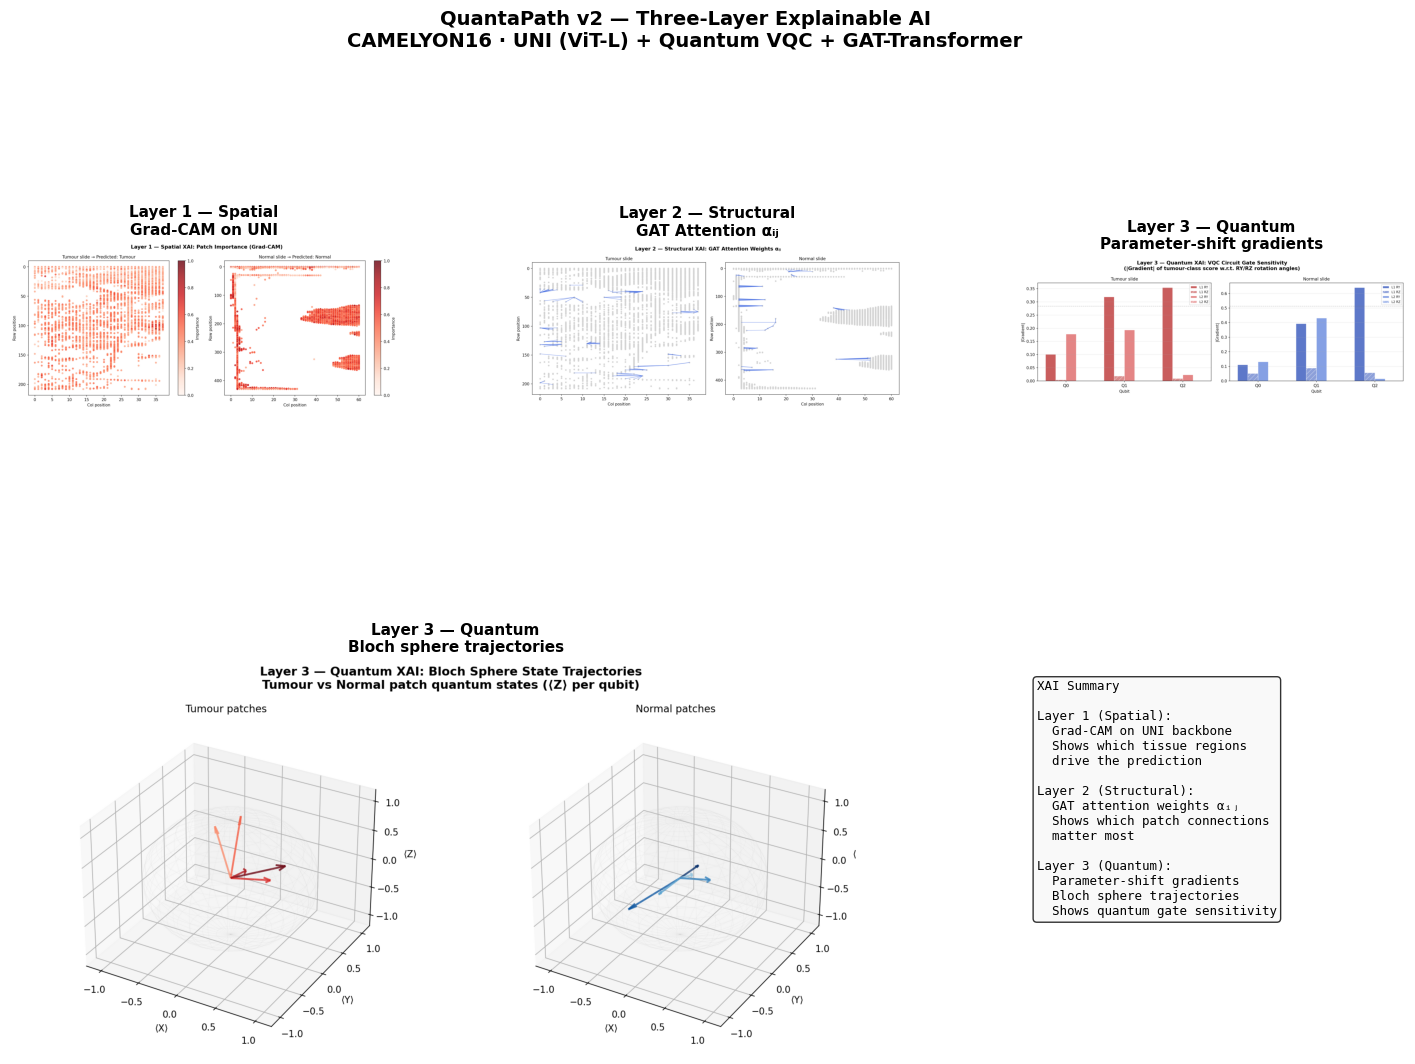

WEEK 6 XAI COMPLETE
Saved: outputs/week6_xai_report.png  ← Paper Figure 3

XAI files created:
  layer1_spatial_gradcam.png
  layer2_structural_gat_attention.png
  layer3_bloch_sphere.png
  layer3_quantum_gradients.png


In [7]:
# Combined paper figure (Figure 3)
from PIL import Image

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'QuantaPath v2 \u2014 Three-Layer Explainable AI\n'
    'CAMELYON16 \u00b7 UNI (ViT-L) + Quantum VQC + GAT-Transformer',
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

xai_files = [
    ('layer1_spatial_gradcam.png',         'Layer 1 \u2014 Spatial\nGrad-CAM on UNI'),
    ('layer2_structural_gat_attention.png','Layer 2 \u2014 Structural\nGAT Attention \u03b1\u1d62\u2c7c'),
    ('layer3_quantum_gradients.png',       'Layer 3 \u2014 Quantum\nParameter-shift gradients'),
    ('layer3_bloch_sphere.png',            'Layer 3 \u2014 Quantum\nBloch sphere trajectories'),
]

positions = [gs[0,0], gs[0,1], gs[0,2], gs[1,0:2]]

for pos, (fname, title) in zip(positions, xai_files):
    fpath = XAI_DIR / fname
    if fpath.exists():
        ax  = fig.add_subplot(pos)
        img = Image.open(fpath)
        ax.imshow(img)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

ax_sum = fig.add_subplot(gs[1, 2])
ax_sum.axis('off')
summary = (
    'XAI Summary\n\n'
    'Layer 1 (Spatial):\n'
    '  Grad-CAM on UNI backbone\n'
    '  Shows which tissue regions\n'
    '  drive the prediction\n\n'
    'Layer 2 (Structural):\n'
    '  GAT attention weights \u03b1\u1d62\u2c7c\n'
    '  Shows which patch connections\n'
    '  matter most\n\n'
    'Layer 3 (Quantum):\n'
    '  Parameter-shift gradients\n'
    '  Bloch sphere trajectories\n'
    '  Shows quantum gate sensitivity'
)
ax_sum.text(0.05, 0.95, summary,
            transform=ax_sum.transAxes,
            fontsize=9, verticalalignment='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#f8f8f8', alpha=0.8))

plt.savefig(OUT_DIR / 'week6_xai_report.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('='*55)
print('WEEK 6 XAI COMPLETE')
print('='*55)
print('Saved: outputs/week6_xai_report.png  \u2190 Paper Figure 3')
print()
print('XAI files created:')
for f in sorted(XAI_DIR.glob('*.png')):
    print(f'  {f.name}')

In [8]:
# Cell 8 — Results summary (uses available JSON files)
import json
from pathlib import Path

OUT = Path('..') / 'outputs'
SEP = '=' * 65

print(SEP)
print(' QUANTAPATH v2 — RESULTS SUMMARY (clean 221-slide data)')
print(SEP)

def load_json(path):
    try:
        with open(path) as f: return json.load(f)
    except FileNotFoundError:
        return None

# ── Main comparison table ─────────────────────────────────────────────────────
print()
print(f" {'Model':<38} {'Val AUC':>8} {'Test AUC':>9} {'F1':>7} {'Gap':>8}")
print(f" {'-'*65}")

rows = [
    ('E3_classical_result.json', 'Classical GAT-Transformer'),
    ('E2_result.json',           'Quantum VQC+GAT  (3q 2L)  ← E2'),
]
for fname, label in rows:
    r = load_json(OUT / fname)
    if r:
        res = r.get('results', r)
        va  = res.get('val_auc', 0)
        ta  = res.get('auc', res.get('test_auc', 0))
        f1  = res.get('f1', 0)
        gap = res.get('gap', ta - va)
        print(f" {label:<38} {va:>8.4f} {ta:>9.4f} {f1:>7.4f} {gap:>+8.4f}")
    else:
        print(f" {label:<38} {'pending':>8}")

# ── Ablation table ────────────────────────────────────────────────────────────
print()
print(f" {'Ablation (512 patches, clean data)':<38} {'Val AUC':>8} {'Test AUC':>9} {'F1':>7} {'Gap':>8}")
print(f" {'-'*65}")

abl = load_json(OUT / 'week4_ablation_fixed.json')
if abl:
    for label, r in abl.get('ablations', {}).items():
        va  = r.get('val_auc', 0)
        ta  = r.get('auc', 0)
        f1  = r.get('f1', 0)
        gap = r.get('gap', 0)
        q   = r.get('n_qubits', '?')
        l   = r.get('n_layers', '?')
        print(f" {label:<38} {va:>8.4f} {ta:>9.4f} {f1:>7.4f} {gap:>+8.4f}")
else:
    print(f" {'week4_ablation_fixed.json':<38} {'pending':>8}")

print(SEP)
print()
print(' XAI figures saved in outputs/xai/:')
for f in sorted((OUT / 'xai').glob('*.png')):
    print(f'   {f.name}')
print()
print(' Paper Figure 3: outputs/week6_xai_report.png')
print(SEP)


 QUANTAPATH v2 — RESULTS SUMMARY (clean 221-slide data)

 Model                                   Val AUC  Test AUC      F1      Gap
 -----------------------------------------------------------------
 Classical GAT-Transformer                0.6618    0.6886  0.6875  +0.0268
 Quantum VQC+GAT  (3q 2L)  ← E2           0.6507    0.6851  0.6875  +0.0344

 Ablation (512 patches, clean data)      Val AUC  Test AUC      F1      Gap
 -----------------------------------------------------------------
 week4_ablation_fixed.json               pending

 XAI figures saved in outputs/xai/:
   layer1_spatial_gradcam.png
   layer2_structural_gat_attention.png
   layer3_bloch_sphere.png
   layer3_quantum_gradients.png

 Paper Figure 3: outputs/week6_xai_report.png
